In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
from langchain_groq import ChatGroq
# model=ChatGroq(model="qwen/qwen3.6-27b")
model=ChatGroq(model="openai/gpt-oss-120b")
print(model)
# print("hello world")

metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}} profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x000001CCCE7CCD60> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CCCE7CD6E0> model_name='openai/gpt-oss-120b' model_kwargs={} groq_api_key=SecretStr('**********')


In [91]:
from pydantic import BaseModel, Field
# node to fetch latest trending vide from the youtube using API.
class ReferenceVideo(BaseModel):
    title:str=Field(description="contains title of the video")
    description:str=Field(description="contains the description of the videos")
    channelTitle:str=Field(description="It is the title of youtube channel")
    tags:list[str]|str|None=Field(description="It contains the list of tags related to video")
import requests
def fetch_trending_video(state):
    video_id=state["video_id"]
    print("fetch trending video node called")
    # res= requests.get("https://abcd.com/")
    # data=res.json()
    # This is the data of that trending video
    data={
        "title":"US Iran War: ईरान पर अमेरिका की ताबड़तोड़ कार्रवाई! ट्रंप बोले- रडार और नौसैनिक ढांचा तबाह | AajTak",
        "channelTitle":"Aajtak",
        "tags":["usiranwar" ,"usattack ","trump ","atwebvideos ","aajtak  ","aajtakdigital" ,"tvchunks"],
        "description":"""ईरान और अमेरिका के बीच तनाव लगातार बढ़ता जा रहा है। अमेरिकी राष्ट्रपति डोनाल्ड ट्रंप ने दावा किया है कि अमेरिकी सेना ने ईरान के रडार और नौसैनिक ढांचे पर बेहद भारी हमले किए हैं। वहीं ईरान की ओर से अमेरिकी हमलों में एक शादी समारोह को निशाना बनाए जाने और बड़ी संख्या में लोगों के हताहत होने का दावा किया गया है।

इस बीच ईरान ने अमेरिकी MQ-9 रीपर ड्रोन को मार गिराने का दावा किया है। आर्थिक मोर्चे पर भी दबाव बढ़ रहा है, जबकि SCO सम्मेलन के दौरान पीएम मोदी और ईरानी राष्ट्रपति मसूद पेज़ेश्कियान की मुलाकात के बाद अमेरिका की ओर से ईरान की आर्थिक मदद या प्रतिबंधों को दरकिनार करने वाले देशों को चेतावनी दी गई है। आखिर ईरान-अमेरिका की इस जंग का अगला मोड़ क्या होगा? 
"""
        

    }
    required_data={}
    required_data["title"]=data["title"]
    required_data["description"]=data["description"]
    required_data["channelTitle"]=data["channelTitle"]
    required_data["tags"]=data["tags"]
    print("result of fetch trending vide node:",required_data)
    return {"refrence_video":required_data}
                


In [92]:
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

@tool
def tavily_search_tool(query:str):
    """This tool is for the websearch. It provides the latest possible data present on internet based on query asked. So queyr is passed to the tool and tool returns the data after performing websearch on the user query."""
    print("here isthe tool called=>")
    search_tool=TavilySearch(
        max_results=2,
        topic="news"
    )
    res=search_tool.invoke(query)
    print("here is tool result==>",res)
    return res


In [93]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from datetime import datetime
class ReleventVideo(BaseModel):
    """Structure of an individual relevant video idea."""

    title: str = Field(
        description="Engaging, clickable, and search-optimized title."
    )
    summary: str = Field(
        description="2-3 sentence overview of the core concept and content flow."
    )
    viewer_hook: str = Field(
        description="Why the reference video viewer would click this."
    )
    relevancy_score: float = Field(
        description="Relevancy score compared to the reference video from 0.0 to 1.0."
    )


class ReleventVideos(BaseModel):
    """Container for the list of generated video ideas."""

    videos: list[ReleventVideo] = Field(
        description="List containing exactly 1 relevant video ideas.",
        min_length=1,
        max_length=1,
    )


def research_agent(state):
    """Researches trending updates and returns 1 validated, structured video concepts."""
    refrence_video = state["refrence_video"]
    current_date=datetime.now()

    # 1. Agent System Prompt: Guides web search & analysis
    agent_system_message = f"""You are an expert news researcher and digital trend analyst.
Today date is {current_date}
Investigate the latest updates, real-time facts, and developing coverage around the reference video below. And you only asks question based on the data of reference video. You don't assume anything from your end.

### Reference Video Details
- **Title:** {refrence_video.get("title", "")}
- **Channel Name:** {refrence_video.get("channelTitle", "")}
- **Description:** {refrence_video.get("description", "")}
- **Tags:** {refrence_video.get("tags", "")}

### Instructions
1. Use your search tool to fetch the latest developments, verified facts, numbers, and reactions.
2. Outline 1 distinct content angles based on the findings:
   - Deep-Dive / Scientific Investigation
   - Follow-Up / Human-Interest
   - Geopolitical / Broader Policy Impact
   - Beginner's Guide / Quick Explainer
3. Present detailed summaries, hooks, and verified context for each concept.
"""
    print("here is the agent decleration")
    agent = create_agent(
        model=model,
        tools=[tavily_search_tool],
        system_prompt=agent_system_message,
    )
    print("here agent decleration ended and agent invocation happen")
    agent_res = agent.invoke({
        "messages": [{
            "role": "user", 
            "content": "Research the latest facts and real-time updates for this video topic. Formulate 1 distinct video angles.",
            
        }]
    })
    print("here agent invocation has ended")
    agent_message = agent_res["messages"][-1].content

    # 2. Structured Output Prompt: Injects the agent's verified research
    structured_system_message = """You are a senior YouTube content strategist.

Your task is to transform the provided verified research and reference video data into exactly 1 high-performing video concept formatted strictly according to the schema.

### Reference Video Metadata
- Title: {ref_title}
- Channel: {ref_channel}
- Description: {ref_desc}

### Editorial Constraints
- Ground every concept strictly in the provided research data.
- The 1 concept must cover diverse angles: Deep-Dive, Human-Interest/Follow-Up, Geopolitical/Macro-Analysis, and Beginner's Guide/Explainer.
- Ensure titles are search-friendly, hooks create curiosity without being misleading, and relevancy scores reflect topical alignment (0.0 to 1.0).
- Adhere strictly to YouTube Community Guidelines."""

    structured_output_prompt = ChatPromptTemplate.from_messages([
        ("system", structured_system_message),
        (
            "human",
            """Below is the verified research report on this topic:

---
{research_data}
---

Generate the 1 structured video concept based on this verified research."""
        ),
    ])

    model_with_structured_output = model.with_structured_output(ReleventVideos)
    chain = structured_output_prompt | model_with_structured_output

    # 3. Invoke chain with reference metadata and research data
    result = chain.invoke({
        "ref_title": refrence_video.get("title", ""),
        "ref_channel": refrence_video.get("channelTitle", ""),
        "ref_desc": refrence_video.get("description", ""),
        "research_data": agent_message,
    })
    return {"relevent_videos":result.videos}
    return result

In [94]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


class RawVideoInput(BaseModel):
    title: str
    summary: str
    viewer_hook: str


class GeneratedVideoData(BaseModel):
    title: str = Field(
        description="High-CTR, curiosity-driven YouTube title under 65 characters without clickbait violation."
    )
    description: str = Field(
        description="SEO-optimized description containing an engaging 2-3-sentence hook, video summary, structured timestamps/key takeaways, and relevant hashtags."
    )
    tags: list[str] = Field(
        description="10 to 15 targeted keywords combining broad reach, niche tags, and long-tail search queries."
    )



def finalize_youtube_content(state):
    relevent_videos=state["relevent_videos"]
    inputs=[{"title":video.title if hasattr(video,"title") else video["title"],
             "summary":video.summary if hasattr(video,"summary") else video["summary"],
             "viewer_hook":video.viewer_hook if hasattr(video,"viewer_hook") else video["viewer_hook"]
             } for video in relevent_videos]
    # System instructions: static role definition and guidelines
    SYSTEM_PROMPT = """You are an elite YouTube strategist and metadata SEO specialist.
    Your goal is to turn raw video ideas into metadata optimized for search discovery, suggested algorithm feed, and high click-through rates (CTR).

    Guidelines:
    1. Title: Front-load high-impact keywords. Keep it under 65 characters so it does not truncate on mobile devices. Elicit curiosity or strong benefit without violating YouTube's deceptive practices policy.
    2. Description:
    - First 2 lines: Compelling hook directly summarizing the value proposition before the "Show More" fold.
    - Body: Core concepts covered and primary takeaways.
    - Bottom: 3-5 highly relevant hashtags.
    3. Tags: Provide 10-15 targeted tags ranging from broad category labels to hyper-specific long-tail phrases.
    """

    # Human message: dynamic data placeholder
    HUMAN_TEMPLATE = """Generate production-ready YouTube metadata using this raw video data:

    - Draft Title: {title}
    - Video Summary: {summary}
    - Hook / Key Angle: {viewer_hook}
    """

    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human", HUMAN_TEMPLATE),
    ])
    structured_model = model.with_structured_output(GeneratedVideoData)
    chain = prompt | structured_model
    final_video_data=chain.batch(inputs)
    print("here is the final_video data:",final_video_data)
    # return final_video_data
    return {"final_video_data":final_video_data}

In [95]:
@tool
def generate_thumb_image(title:str,description:str|None=''):
    """This tool generates the thumbnail image from the title and description of the video."""
    print("here is title and description:",title)
    return "https://image/"+"_".join(title[:10])

class CombineVideoData(GeneratedVideoData):
    thumb_image:str=Field(description="It contains the thumb url of the video")

def generate_thumbnail(state):
    final_video_data=state["final_video_data"]
    inputs=[{"title":video.title,"description":video.description} for video in final_video_data]
    thumbnails=generate_thumb_image.batch(inputs)
    print("here are all the thumbnails==>",thumbnails)
    combined_videos = [
        {
            **video.model_dump(),     # Unpacks title, description, tags, etc.
            "thumb_image": thumb      # Adds the thumbnail result
        }
        for video, thumb in zip(final_video_data, thumbnails)
    ]
    
    print("Combined video package:", combined_videos)
    return {"final_video_package": combined_videos}

In [96]:
from typing_extensions import TypedDict
class State(TypedDict):
    video_id:str
    refrence_video:ReferenceVideo
    relevent_videos:ReleventVideos
    final_video_data:GeneratedVideoData
    final_video_package:CombineVideoData

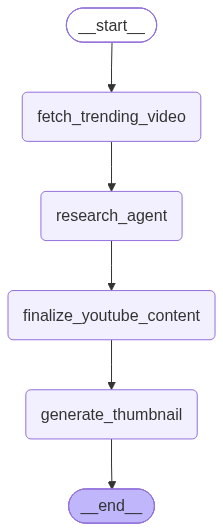

In [97]:
from langgraph.graph import StateGraph, START,END
from IPython.display import display, Image
builder=StateGraph(State)

builder.add_node("fetch_trending_video",fetch_trending_video)
builder.add_node("research_agent",research_agent)
builder.add_node("finalize_youtube_content",finalize_youtube_content)
builder.add_node("generate_thumbnail",generate_thumbnail)

builder.add_edge(START, "fetch_trending_video")
builder.add_edge("fetch_trending_video","research_agent")
builder.add_edge("research_agent","finalize_youtube_content")
builder.add_edge("finalize_youtube_content","generate_thumbnail")
builder.add_edge("generate_thumbnail",END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [98]:
res = graph.invoke(
    {"video_id": "abcd"},
    {"recursion_limit": 10}
)

fetch trending video node called
result of fetch trending vide node: {'title': 'US Iran War: ईरान पर अमेरिका की ताबड़तोड़ कार्रवाई! ट्रंप बोले- रडार और नौसैनिक ढांचा तबाह | AajTak', 'description': 'ईरान और अमेरिका के बीच तनाव लगातार बढ़ता जा रहा है। अमेरिकी राष्ट्रपति डोनाल्ड ट्रंप ने दावा किया है कि अमेरिकी सेना ने ईरान के रडार और नौसैनिक ढांचे पर बेहद भारी हमले किए हैं। वहीं ईरान की ओर से अमेरिकी हमलों में एक शादी समारोह को निशाना बनाए जाने और बड़ी संख्या में लोगों के हताहत होने का दावा किया गया है।\n\nइस बीच ईरान ने अमेरिकी MQ-9 रीपर ड्रोन को मार गिराने का दावा किया है। आर्थिक मोर्चे पर भी दबाव बढ़ रहा है, जबकि SCO सम्मेलन के दौरान पीएम मोदी और ईरानी राष्ट्रपति मसूद पेज़ेश्कियान की मुलाकात के बाद अमेरिका की ओर से ईरान की आर्थिक मदद या प्रतिबंधों को दरकिनार करने वाले देशों को चेतावनी दी गई है। आखिर ईरान-अमेरिका की इस जंग का अगला मोड़ क्या होगा? \n', 'channelTitle': 'Aajtak', 'tags': ['usiranwar', 'usattack ', 'trump ', 'atwebvideos ', 'aajtak  ', 'aajtakdigital', 'tvchunks']}
here is

In [99]:
res["final_video_package"]

[{'title': 'Radar Raid Sparks US‑Iran Drone Shoot‑Down & 48‑Hour Oil Spike',
  'description': 'If you thought US‑Iran tensions were just political hot‑air, watch how a single radar strike ignited a two‑day kinetic showdown – a downed MQ‑9 Reaper, missile barrages across the Gulf, and a 3% surge in oil prices.\n\nIn this deep‑dive we break down:\n0:00 – Intro: Why the radar raid matters\n1:45 – Trump’s “devastating” claim & CENTCOM strike confirmation\n4:20 – IRGC footage: MQ‑9 Reaper shot down over the Persian Gulf\n7:10 – Coordinated missile attacks on U.S. bases in Jordan, Bahrain & Kuwait\n10:55 – Civilian voices from Kuhestak & Pentagon insider testimony\n13:30 – Oil market reaction: 3% price spike and global implications\n16:15 – Geopolitical ripple: SCO‑India‑Iran summit, allied responses\n19:40 – Future scenarios: diplomatic de‑escalation, escalation, U.S. strategic realignment\n22:00 – Key takeaways & what to watch next\n\nStay informed on the fast‑moving Gulf flashpoint and wh